In [133]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
import adiabatic_approx_func as adprox
import kibble_zurek as kz

In [134]:
def defect_exact(n,state):
    return 1/2- Px(n,state)
def defect_approx(n,tau):
    return 1/2 - adprox.P_n(n,tau)

def compute_exact(j, st):
    return j, [
        defect_exact(n, st)
        for n in tqdm(ns, leave=False, desc=f"n (state {j})")
    ]
def compute_approx(j, tau):
    return j, [defect_approx(n,tau) for n in tqdm(ns,leave=False,desc=f"n approx (state {j})")]

In [135]:
N_tau = 200
L = 500
taus = np.logspace(-0,3,N_tau)

states = Parallel(n_jobs=-1)(
    delayed(state)(L, tau, tau) for tau in taus
)


In [136]:
ns = np.arange(1, 15)
f_exact = np.zeros((len(ns), len(taus)))
f_approx = np.zeros((len(ns), len(taus)))   # shape (Nn , Nt)

# fill grid
for i, n in enumerate(ns):
    for j, tau in enumerate(taus):
        f_approx[i,j] = defect_approx(n, tau)


results_exact = Parallel(n_jobs=-1)(
    delayed(compute_exact)(j, st)
    for j, st in tqdm(list(enumerate(states)), desc="states")
)


results_approx = Parallel(n_jobs=-1)(delayed(compute_approx)(j,tau) for j, tau in tqdm(list(enumerate(taus)), 
                                                                                     desc="states approx"
                                                                                     ))
for j, col in results_exact:
    f_exact[:, j] = col
for j, col in results_approx:
    f_approx[:,j] = col


/home/kristian/Desktop/subsystem_loschmidt_echo/scripts/analytical_adiabatic_theory breakdown/adiabatic_approx_func.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  exp1 = np.exp((2j)/v - (r**2 * v * (np.pi - 1j*np.log(v))) / (4 * np.log(v)**2))
/home/kristian/Desktop/subsystem_loschmidt_echo/scripts/analytical_adiabatic_theory breakdown/adiabatic_approx_func.py:20: RuntimeWarning: invalid value encountered in scalar divide
  exp1 = np.exp((2j)/v - (r**2 * v * (np.pi - 1j*np.log(v))) / (4 * np.log(v)**2))
/home/kristian/Desktop/subsystem_loschmidt_echo/scripts/analytical_adiabatic_theory breakdown/adiabatic_approx_func.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  exp2 = np.exp(-(2j)/v - (r**2 * v * (np.pi + 1j*np.log(v))) / (4 * np.log(v)**2))
/home/kristian/Desktop/subsystem_loschmidt_echo/scripts/analytical_adiabatic_theory breakdown/adiabatic_approx_func.py:21: RuntimeWarning: invalid value encountered in scalar divide
  exp2 = np.exp(-(2j

Text(0.5, 0.98, 'Comparison of Exact to Approx')

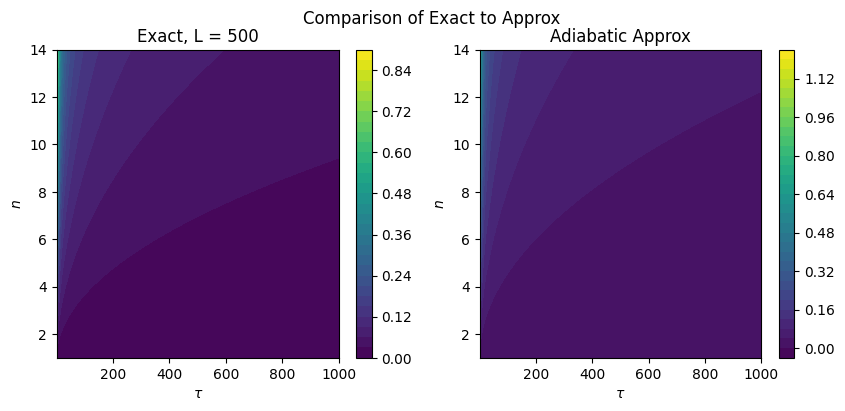

In [150]:
fig, axs = plt.subplots(1,2,figsize=(10,4))
exactplot = axs[0].contourf((taus), ns, f_exact*2, levels=30)

axs[0].set_xlabel(r'$\tau$')
axs[0].set_ylabel(r'$n$')
axs[0].set_title(f"Exact, L = {L}")
cbar0 = fig.colorbar(exactplot, ax=axs[0])
approxplot = axs[1].contourf((taus), ns, f_approx*2, levels=30)

axs[1].set_xlabel(r'$\tau$')
axs[1].set_ylabel(r'$n$')
axs[1].set_title("Adiabatic Approx")
cbar1 = fig.colorbar(approxplot, ax=axs[1])

fig.suptitle("Comparison of Exact to Approx")


#axs[1].set_xscale('log')



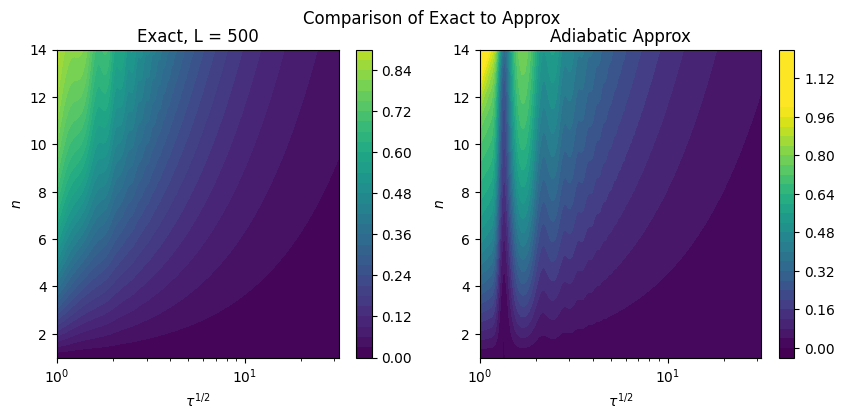

In [151]:
fig, axs = plt.subplots(1,2,figsize=(10,4))
exactplot = axs[0].contourf(sqrt(taus), ns, f_exact*2, levels=30,vmin=0,vmax=1)

axs[0].set_xlabel(r'$\tau^{1/2}$')
axs[0].set_ylabel(r'$n$')
axs[0].set_title(f"Exact, L = {L}")
cbar0 = fig.colorbar(exactplot, ax=axs[0])
approxplot = axs[1].contourf(sqrt(taus), ns, f_approx*2, levels=30,vmin=0,vmax=1)

axs[1].set_xlabel(r'$\tau^{1/2}$')
axs[1].set_ylabel(r'$n$')
axs[1].set_title("Adiabatic Approx")
cbar1 = fig.colorbar(approxplot, ax=axs[1])

fig.suptitle("Comparison of Exact to Approx")


axs[1].set_xscale('log')
axs[0].set_xscale('log')



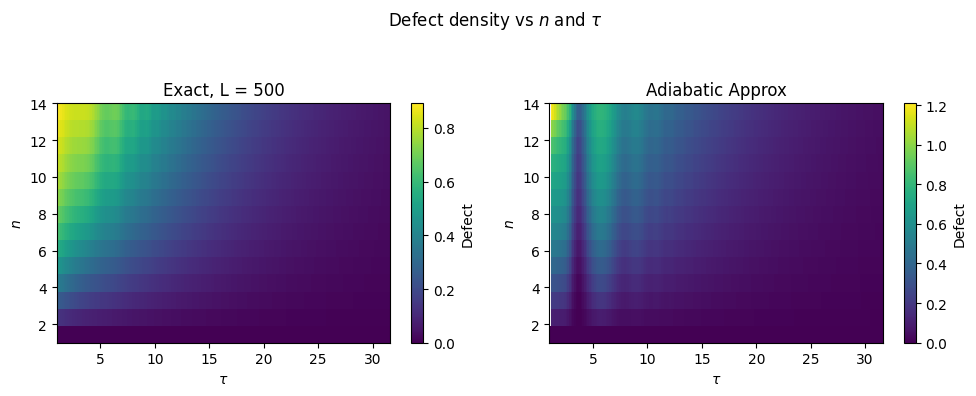

In [152]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(
    2*f_exact,
    origin="lower",
    aspect="auto",
    interpolation="none",   # raw pixels
    extent=[sqrt(taus[0]), sqrt(taus[-1]), ns[0], ns[-1]]
)
axs[0].set_xlabel(r"$\tau$")
axs[0].set_ylabel(r"$n$")
axs[0].set_title(f"Exact, L = {L}")
fig.colorbar(im0, ax=axs[0], label="Defect")

im1 = axs[1].imshow(
    2*f_approx,
    origin="lower",
    aspect="auto",
    interpolation="none",   # raw pixels
    extent=[sqrt(taus[0]), sqrt(taus[-1]), ns[0], ns[-1]]
)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel(r"$n$")
axs[1].set_title("Adiabatic Approx")
fig.colorbar(im1, ax=axs[1], label="Defect")

fig.suptitle("Defect density vs $n$ and $\\tau$")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


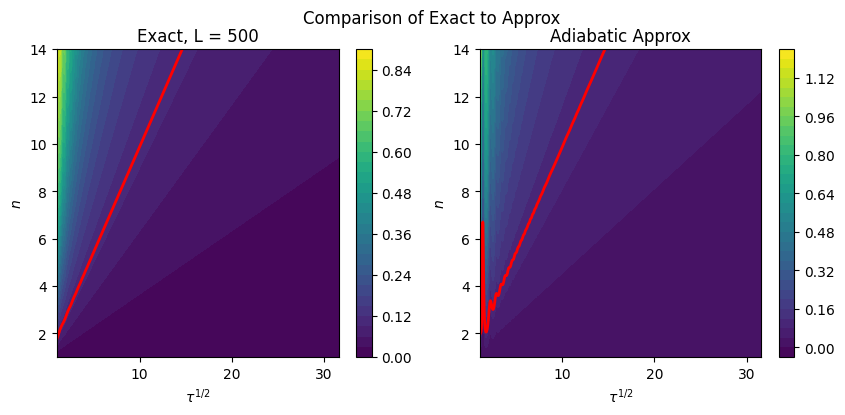

In [153]:
fig, axs = plt.subplots(1,2,figsize=(10,4))
exactplot = axs[0].contourf(sqrt(taus), ns, f_exact*2, levels=30)

axs[0].set_xlabel(r'$\tau^{1/2}$')
axs[0].set_ylabel(r'$n$')
axs[0].set_title(f"Exact, L = {L}")
cbar0 = fig.colorbar(exactplot, ax=axs[0])
approxplot = axs[1].contourf(sqrt(taus), ns, f_approx*2, levels=30)

axs[1].set_xlabel(r'$\tau^{1/2}$')
axs[1].set_ylabel(r'$n$')
axs[1].set_title("Adiabatic Approx")
cbar1 = fig.colorbar(approxplot, ax=axs[1])

fig.suptitle("Comparison of Exact to Approx")


# axs[1].set_xscale('log')
# axs[0].set_xscale('log')

####
level = .05  # choose your constant value f(n,τ)=level

# draw the constant-defect line
cs = axs[1].contour(sqrt(taus), ns, f_approx,levels=[level],colors="red", linewidths=2)
cs = axs[0].contour(sqrt(taus), ns, f_exact,levels=[level],colors="red", linewidths=2)
show()


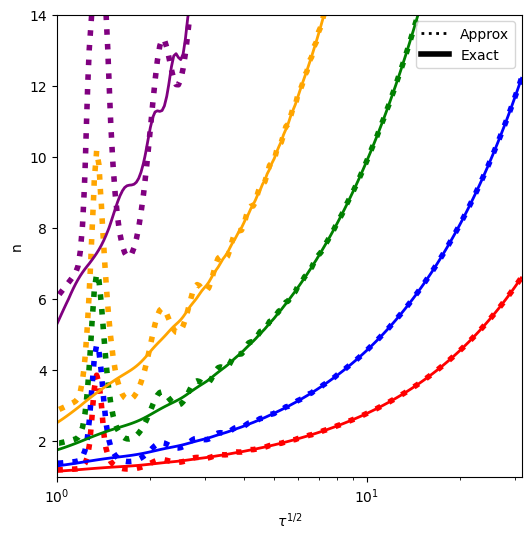

In [158]:
from matplotlib.lines import Line2D
level_num = [0.01, 0.02, 0.05, .1,.25]
colors = ["red", "blue", "green", "orange","purple"]
plt.figure(figsize=(6,6))

for level,color in zip(level_num,colors):

    plt.contour(np.sqrt(taus), ns, f_approx,
                levels=[level], colors=color, linewidths=4, linestyles=":")

    plt.contour(np.sqrt(taus), ns, f_exact,
                levels=[level], colors=color, linewidths=2, linestyles="-")

plt.xlabel(r"$\tau^{1/2}$")
plt.ylabel("n")

handles = [
    Line2D([0], [0], color="black", lw=2, linestyle=":", label="Approx"),
    Line2D([0], [0], color="black",  lw=4, linestyle="-",  label="Exact"),
]

plt.legend(handles=handles)
xscale("log")

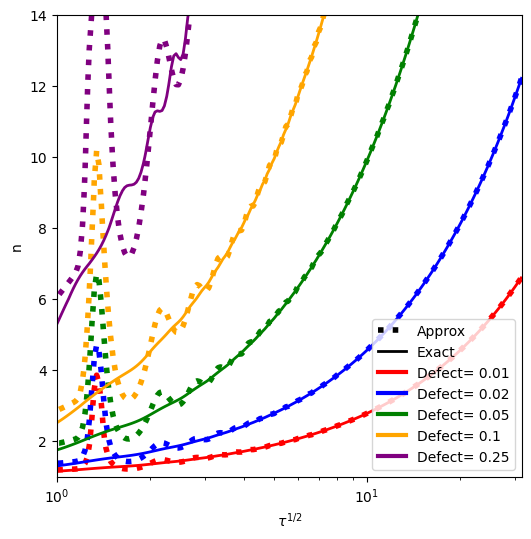

In [195]:
from matplotlib.lines import Line2D

level_num = [0.01, 0.02, 0.05, .1, .25]
colors = ["red", "blue", "green", "orange", "purple"]

plt.figure(figsize=(6,6))
for level, color in zip(level_num, colors):
    plt.contour(np.sqrt(taus), ns, f_approx, levels=[level],
                colors=color, linewidths=4, linestyles=":")
    plt.contour(np.sqrt(taus), ns, f_exact, levels=[level],
                colors=color, linewidths=2, linestyles="-")

plt.xlabel(r"$\tau^{1/2}$")
plt.ylabel("n")
plt.xscale("log")

style_handles = [
    Line2D([0], [0], color="black", lw=4, linestyle=":", label="Approx"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Exact"),
]
level_handles = [
    Line2D([0], [0], color=c, lw=3, label=f"Defect= {lvl}")
    for lvl, c in zip(level_num, colors)
]

plt.legend(handles=style_handles + level_handles,loc="lower right")


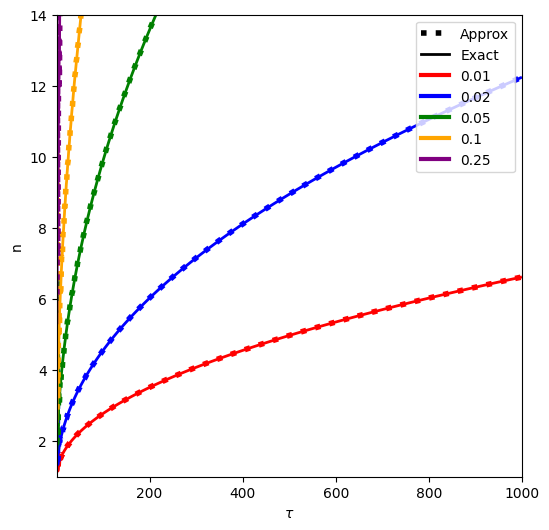

In [192]:
from matplotlib.lines import Line2D

level_num = [0.01, 0.02, 0.05, .1, .25]
colors = ["red", "blue", "green", "orange", "purple"]

plt.figure(figsize=(6,6))
for level, color in zip(level_num, colors):
    plt.contour((taus), ns, f_approx, levels=[level],
                colors=color, linewidths=4, linestyles=":")
    plt.contour((taus), ns, f_exact, levels=[level],
                colors=color, linewidths=2, linestyles="-")

plt.xlabel(r"$\tau$")
plt.ylabel("n")
#plt.xscale("log")

style_handles = [
    Line2D([0], [0], color="black", lw=4, linestyle=":", label="Approx"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Exact"),
]
level_handles = [
    Line2D([0], [0], color=c, lw=3, label=f"{lvl}")
    for lvl, c in zip(level_num, colors)
]

plt.legend(handles=style_handles + level_handles)
